### Explanation of the Code

Chunk 1: CORRA Rate & Interest Calculation


This code goes online to the Bank of Canada's website and grabs the most up-to-date Canadian Overnight Repo Rate Average (called the CORRA rate). It then takes that rate and adds a small, fixed fee to it. The final number is the total annual interest rate that's used for all the future calculations.

---

Chunk 2: Futures Price Retrieval from IBKR-TWS

Connects the TWS API from Interactive Brokers & to get the **last closing prices** Canola futures contracts. You can change socket# to  7497 to connect to IBKR Gateway

---
Cost-of-Carry & Heatmap

Takes the interest rate from Chunk #1 + Prices and calculates the **Cost of Carry**, for every possible combination of futures contracts. 
Finally, it displays it as color-coded **heatmap chart**. 

In [1]:
# --- Cell 1: Fetch Interest Rate ---
import requests

BOC_CORRA_URL = "https://www.bankofcanada.ca/valet/observations/group/CORRA/json"
FIXED_SPREAD = 0.0225

def get_live_corra() -> float:
    try:
        response = requests.get(BOC_CORRA_URL, timeout=5)
        response.raise_for_status()
        data = response.json()
        observations = data.get('observations', [])
        if observations:
            latest_observation = observations[-1]
            if 'AVG.INTWO' in latest_observation and 'v' in latest_observation['AVG.INTWO']:
                return float(latest_observation['AVG.INTWO']['v'])
    except Exception:
        pass
    return None

# Fetch data and store into raw variables
raw_corra = get_live_corra()
if raw_corra is not None:
    interest_rate_per_annum = (raw_corra / 100) + FIXED_SPREAD
else:
    interest_rate_per_annum = (2.25 / 100) + FIXED_SPREAD

Targeting curve pipeline: ['X26', 'F27', 'H27', 'K27', 'N27', 'X27']
✅ Price for X26: $743.70
✅ Price for F27: $751.30
✅ Price for H27: $757.30
✅ Price for K27: $758.40

  Spread  Value VSR %
X26-F27   -7.6 46.4%
X26-H27  -13.6 42.2%
X26-K27  -14.7 30.3%
F27-H27   -6.0 37.8%
F27-K27   -7.1 22.0%
H27-K27   -1.1  6.7%


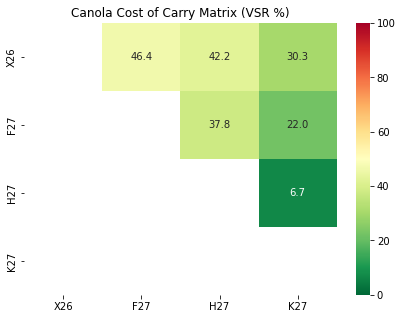

In [2]:
import time
import threading
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import date, timedelta
from typing import Dict, Optional, List, Tuple
from ibapi.client import EClient
from ibapi.wrapper import EWrapper
from ibapi.contract import Contract

# --- GLOBAL CONFIGURATIONS ---
DAILY_STORAGE_RATE = 0.1750
MONTH_CODES = {'F': '01', 'H': '03', 'K': '05', 'N': '07', 'X': '11'}
MONTH_ORDER = ['F', 'H', 'K', 'N', 'X'] # Chronological order of Canola contracts

class CanolaPriceApp(EClient, EWrapper):
    def __init__(self):
        EClient.__init__(self, self)
        EWrapper.__init__(self)
        self.prices: Dict[int, float] = {}
        self.reqId_to_contract: Dict[int, str] = {}
        self.req_events: Dict[int, threading.Event] = {}
        self.nextOrderId: Optional[int] = None
        self.resolved_contracts: Dict[str, Contract] = {} 
        
    def error(self, reqId: int, errorCode: int, errorString: str, advancedOrderReject: str = ""):
        if errorCode in [2104, 2106, 2158]: return # Ignore connection status updates
        if reqId in self.req_events: self.req_events[reqId].set()

    def nextValidId(self, orderId: int):
        super().nextValidId(orderId)
        self.nextOrderId = orderId

    def contractDetails(self, reqId: int, contractDetails):
        contract_code = self.reqId_to_contract.get(reqId, "UNKNOWN")
        self.resolved_contracts[contract_code] = contractDetails.contract

    def contractDetailsEnd(self, reqId: int):
        if reqId in self.req_events: self.req_events[reqId].set()

    def historicalData(self, reqId: int, bar):
        if bar.close > 0:
            self.prices[reqId] = bar.close
            contract_code = self.reqId_to_contract.get(reqId, "UNKNOWN")
            print(f"✅ Price for {contract_code}: ${bar.close:,.2f}")

    def historicalDataEnd(self, reqId: int, start: str, end: str):
        if reqId in self.req_events: self.req_events[reqId].set()

# --- HELPER LOGIC GENERATORS ---

def generate_contract_range(start_yr: int, end_yr: int, start_mth: str, end_mth: str) -> List[str]:
    """Dynamically builds the chronological contract list within user limits."""
    curve = []
    start_score = start_yr + (MONTH_ORDER.index(start_mth) / 10.0)
    end_score = end_yr + (MONTH_ORDER.index(end_mth) / 10.0)
    
    for yr in range(start_yr, end_yr + 1):
        for mth in MONTH_ORDER:
            current_score = yr + (MONTH_ORDER.index(mth) / 10.0)
            if start_score <= current_score <= end_score:
                curve.append(f"{mth}{str(yr)[2:]}") # Formats to 'X26', 'F27', etc.
    return curve

def get_dynamic_fnd(contract_code: str) -> date:
    """Calculates theoretical First Notice Day (1st business day of contract month)."""
    mth_letter = contract_code[0]
    year = int(f"20{contract_code[1:]}")
    month = int(MONTH_CODES[mth_letter])
    return date(year, month, 1)

def fetch_canola_prices_for_spreads(contracts: List[str]) -> Dict[str, float]:
    app = CanolaPriceApp()
    client_id = random.randint(10, 99)
    app.connect('127.0.0.1', 7496, clientId=client_id)
    
    thread = threading.Thread(target=app.run, daemon=True)
    thread.start()
    
    while app.nextOrderId is None: time.sleep(0.1)

    yesterday = date.today() - timedelta(days=1)
    end_date_str = yesterday.strftime("%Y%m%d 23:59:59 US/Eastern")
    final_prices = {}
    
    for i, code in enumerate(contracts):
        req_id = app.nextOrderId + i
        app.reqId_to_contract[req_id] = code
        
        # Build TWS Contract mapping object
        c = Contract()
        c.symbol, c.secType, c.exchange, c.currency = 'RS', 'FUT', 'NYBOT', 'CAD'
        c.lastTradeDateOrContractMonth = f"20{code[1:]}{MONTH_CODES[code[0]]}"
        
        # Resolve explicit exact day metadata
        app.req_events[req_id] = threading.Event()
        app.reqContractDetails(reqId=req_id, contract=c)
        
        if app.req_events[req_id].wait(timeout=4) and code in app.resolved_contracts:
            app.req_events[req_id].clear()
            app.reqHistoricalData(req_id, app.resolved_contracts[code], end_date_str, '1 D', '1 day', 'TRADES', 1, 1, False, [])
            if app.req_events[req_id].wait(timeout=5) and req_id in app.prices:
                final_prices[code] = app.prices[req_id]
                
    app.disconnect()
    return final_prices

# --- MATRIX MATH & VISUALIZATION ---

def process_vsr_analysis(contracts: List[str], prices: Dict[str, float], interest_rate: float):
    valid_contracts = [c for c in contracts if c in prices]
    n = len(valid_contracts)
    if n < 2:
        print("\n❌ Calculation halted: Insufficient matching liquid contracts returned.")
        return
        
    matrix_data = np.full((n, n), np.nan)
    spread_list = []
    
    for i, nearby in enumerate(valid_contracts):
        for j, deferred in enumerate(valid_contracts):
            if i < j:
                spread_val = prices[nearby] - prices[deferred]
                days = (get_dynamic_fnd(deferred) - get_dynamic_fnd(nearby)).days
                
                full_carry = -((interest_rate / 365 * prices[nearby]) + DAILY_STORAGE_RATE) * days
                vsr_pct = (spread_val / full_carry * 100) if full_carry != 0 else 0
                matrix_data[i, j] = round(vsr_pct, 1)
                
                spread_list.append({'Spread': f'{nearby}-{deferred}', 'Value': spread_val, 'VSR %': f'{vsr_pct:.1f}%'})

    # Output print summaries
    print("\n", pd.DataFrame(spread_list).to_string(index=False))
    
    # Heatmap rendering
    plt.figure(figsize=(7, 5))
    sns.heatmap(matrix_data, annot=True, fmt=".1f", cmap="RdYlGn_r", xticklabels=valid_contracts, yticklabels=valid_contracts, vmin=0, vmax=100)
    plt.title('Canola Cost of Carry Matrix (VSR %)')
    plt.show()

# --- RUN ENGINE ---
if __name__ == "__main__":
    # --- USER INPUTS ---
    start_year, end_year = 2026, 2027
    start_month, end_month = 'X', 'X'
    
    # Dynamic generation
    target_curve = generate_contract_range(start_year, end_year, start_month, end_month)
    print(f"Targeting curve pipeline: {target_curve}")
    
    # Financial metrics & executions
    corra_interest_baseline = 0.0458 # Populated from your Chunk 1 output
    market_prices = fetch_canola_prices_for_spreads(target_curve)
    process_vsr_analysis(target_curve, market_prices, corra_interest_baseline)

In [3]:
# --- Cell 3: Separate Printout Cell ---

print("=== INTEREST RATE BREAKDOWN ===")
if raw_corra is not None:
    print(f"Base CORRA Rate:     {raw_corra:.4f}%")
else:
    print("Base CORRA Rate:     2.7500% (Using Static Fallback)")
print(f"Broker Spread:       {FIXED_SPREAD * 100:.4f}%")
print(f"TOTAL APPLIED RATE:  {interest_rate_per_annum * 100:.2f}%")
print("===============================\n")

# Process and display the matrix and tables cleanly
#process_vsr_analysis(target_curve, market_prices, interest_rate_per_annum)

=== INTEREST RATE BREAKDOWN ===
Base CORRA Rate:     2.3300%
Broker Spread:       2.2500%
TOTAL APPLIED RATE:  4.58%

